# Notebook 2 — Contextual Image2Text

Este notebook toma como entrada las salidas del notebook anterior y genera descripciones contextuales para las figuras del paper usando:

- el **crop de la figura**
- el **OCR de bloques de texto** de la misma página
- una **caption visual base** con Florence-2
- una **fusión heurística** entre evidencia visual y textual

## Entradas esperadas del Notebook 1

Se asume la estructura de salidas:

- `data/outputs/{run_name}/06_figures/`
- `data/outputs/{run_name}/08_ocr_json/`
- `data/outputs/{run_name}/11_manifests/detections.csv`

## Salidas de este notebook

- `data/outputs/{run_name}/12_image2text/contextual_image2text_results.json`
- `data/outputs/{run_name}/12_image2text/contextual_image2text_results.csv`

## 1. Imports

In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ast

from PIL import Image
from transformers import AutoModelForCausalLM, AutoProcessor
from tqdm.auto import tqdm

c:\Users\user\proyectos\vision-docs\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuración

Ajusta `RUN_NAME` para apuntar a la corrida generada por el notebook anterior.

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for base in [start, *start.parents]:
        markers = [
            ("data", "notebooks"),
            ("src", "data"),
            ("pyproject.toml",),
            ("requirements.txt",),
        ]
        if any(all((base / m).exists() for m in group) for group in markers):
            return base
    return start

PROJECT_ROOT = find_project_root()

RUN_NAME = "paper_run_001"   # <-- cambia esto si tu corrida tiene otro nombre

FLORENCE_MODEL_NAME = "microsoft/Florence-2-base"  # usa "microsoft/Florence-2-large" si tienes más VRAM
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
FLORENCE_TASK_PROMPT = "<MORE_DETAILED_CAPTION>"

INPUT_DIRS = {
    "root": PROJECT_ROOT / "data" / "outputs" / RUN_NAME,
    "figures": PROJECT_ROOT / "data" / "outputs" / RUN_NAME / "06_figures",
    "ocr_json": PROJECT_ROOT / "data" / "outputs" / RUN_NAME / "08_ocr_json",
    "manifests": PROJECT_ROOT / "data" / "outputs" / RUN_NAME / "11_manifests",
}

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / RUN_NAME / "12_image2text"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_JSON_PATH = OUTPUT_DIR / "contextual_image2text_results.json"
RESULTS_CSV_PATH = OUTPUT_DIR / "contextual_image2text_results.csv"

# Heurísticas
MAX_VERTICAL_GAP = 260
MAX_HORIZONTAL_EXPAND = 140
MAX_NEARBY_BLOCKS = 8
MAX_MENTION_BLOCKS = 5

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RUN_NAME:", RUN_NAME)
print("DEVICE:", DEVICE)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: C:\Users\user\proyectos\vision-docs
RUN_NAME: paper_run_001
DEVICE: cpu
OUTPUT_DIR: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\12_image2text


## 3. Validación de entradas

In [3]:
required_paths = {
    "figures_dir": INPUT_DIRS["figures"],
    "ocr_json_dir": INPUT_DIRS["ocr_json"],
    "detections_csv": INPUT_DIRS["manifests"] / "detections.csv",
}

for name, path in required_paths.items():
    print(f"{name}: {path} | exists={path.exists()}")

missing = [name for name, path in required_paths.items() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Faltan entradas del notebook 1: " + ", ".join(missing)
    )

figures_dir: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\06_figures | exists=True
ocr_json_dir: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\08_ocr_json | exists=True
detections_csv: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\11_manifests\detections.csv | exists=True


## 4. Carga de detecciones

Usamos `detections.csv` para reconstruir las figuras detectadas y vincularlas con sus crops.

In [4]:
detections_df = pd.read_csv(INPUT_DIRS["manifests"] / "detections.csv")
print("Detecciones totales:", len(detections_df))
display(detections_df.head())

figures_df = detections_df[detections_df["kind"] == "figure"].copy().reset_index(drop=True)
text_df = detections_df[detections_df["kind"] == "text"].copy().reset_index(drop=True)

print("Figuras:", len(figures_df))
print("Bloques de texto:", len(text_df))
display(figures_df.head())

Detecciones totales: 32


,page_num,kind,bbox,score,source,meta
0,1,text,"(424, 934, 1479, 1330)",0.993083,ppstructure,NaN
1,1,text,"(427, 1373, 1478, 1438)",0.960642,ppstructure,NaN
2,1,text,"(319, 2225, 926, 2291)",0.931423,ppstructure,NaN
3,1,text,"(421, 1664, 1482, 1807)",0.930575,ppstructure,NaN
4,1,text,"(430, 713, 1473, 744)",0.910238,ppstructure,NaN


Figuras: 1
Bloques de texto: 30


,page_num,kind,bbox,score,source,meta
0,4,figure,"(391, 261, 1548, 1104)",0.971004,ppstructure,NaN


## 5. Reconstrucción de OCR por página

El notebook 1 guardó un JSON por bloque de texto en `08_ocr_json`.
Aquí reconstruimos una estructura cómoda:

```python
ocr_blocks_by_page[page_num] = [
    {"text": "...", "bbox": (x1, y1, x2, y2), "score": ...},
    ...
]
```

In [5]:
def normalize_bbox_values(x1, y1, x2, y2):
    return (int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2)))

def polygon_to_bbox(poly: List[List[float]]) -> Tuple[int, int, int, int]:
    xs = [float(p[0]) for p in poly]
    ys = [float(p[1]) for p in poly]
    return (
        int(round(min(xs))),
        int(round(min(ys))),
        int(round(max(xs))),
        int(round(max(ys))),
    )

def clean_text(text: str) -> str:
    return re.sub(r"\s+", " ", str(text or "")).strip()

def load_ocr_blocks_from_json(ocr_json_dir: Path) -> Dict[int, List[Dict[str, Any]]]:
    """
    Reconstruye bloques OCR por página desde archivos con estructura:
    {
      "page_num": ...,
      "region": {"bbox": [x1,y1,x2,y2], ...},
      "ocr_lines": [{"box": [[x,y],...], "text": "...", "score": ...}, ...]
    }

    Importante:
    - region.bbox está en coordenadas de página
    - ocr_lines[*].box está en coordenadas locales relativas a la región
    - por eso se hace un offset con region.bbox[:2]
    """
    ocr_blocks_by_page: Dict[int, List[Dict[str, Any]]] = {}
    skipped = []

    json_files = sorted(ocr_json_dir.glob("*.json"))

    for json_file in json_files:
        try:
            payload = json.loads(json_file.read_text(encoding="utf-8"))
        except Exception as e:
            skipped.append((json_file.name, f"json_error: {e}"))
            continue

        page_num = payload.get("page_num", None)
        region = payload.get("region", {}) or {}
        region_bbox = region.get("bbox", None)
        ocr_lines = payload.get("ocr_lines", []) or []

        if not isinstance(page_num, int) or page_num < 1:
            skipped.append((json_file.name, "page_num inválido"))
            continue

        if not isinstance(region_bbox, list) or len(region_bbox) != 4:
            skipped.append((json_file.name, "region.bbox inválido"))
            continue

        if not isinstance(ocr_lines, list) or len(ocr_lines) == 0:
            skipped.append((json_file.name, "sin ocr_lines"))
            continue

        rx1, ry1, rx2, ry2 = [int(round(v)) for v in region_bbox]

        page_blocks = []
        full_text_parts = []
        line_scores = []

        for line in ocr_lines:
            text = clean_text(line.get("text", ""))
            poly = line.get("box", None)
            score = float(line.get("score", 1.0))

            if not text:
                continue
            if not isinstance(poly, list) or len(poly) < 4:
                continue

            try:
                lx1, ly1, lx2, ly2 = polygon_to_bbox(poly)
            except Exception:
                continue

            # Convertir bbox local -> bbox en coordenadas de página
            gx1 = rx1 + lx1
            gy1 = ry1 + ly1
            gx2 = rx1 + lx2
            gy2 = ry1 + ly2

            page_blocks.append({
                "text": text,
                "bbox": (gx1, gy1, gx2, gy2),
                "score": score,
                "source_json": str(json_file),
                "level": "line",
            })

            full_text_parts.append(text)
            line_scores.append(score)

        # Además guardar el bloque agregado de toda la región
        if page_blocks:
            region_text = clean_text(" ".join(full_text_parts))
            region_score = sum(line_scores) / max(1, len(line_scores))

            page_blocks.append({
                "text": region_text,
                "bbox": (rx1, ry1, rx2, ry2),
                "score": region_score,
                "source_json": str(json_file),
                "level": "region",
            })

            ocr_blocks_by_page.setdefault(page_num, []).extend(page_blocks)
        else:
            skipped.append((json_file.name, "ocr_lines sin líneas válidas"))

    # Orden de lectura aproximado: arriba -> abajo, izquierda -> derecha
    for page_num in ocr_blocks_by_page:
        ocr_blocks_by_page[page_num] = sorted(
            ocr_blocks_by_page[page_num],
            key=lambda b: (b["bbox"][1], b["bbox"][0], 0 if b["level"] == "line" else 1)
        )

    print("Archivos OCR leídos:", len(json_files))
    print("Páginas reconstruidas:", len(ocr_blocks_by_page))
    print("Bloques OCR totales:", sum(len(v) for v in ocr_blocks_by_page.values()))

    if skipped:
        print("\nPrimeros archivos omitidos:")
        for item in skipped[:10]:
            print(" -", item)

    return ocr_blocks_by_page


ocr_blocks_by_page = load_ocr_blocks_from_json(INPUT_DIRS["ocr_json"])

if not ocr_blocks_by_page:
    raise ValueError("No se pudo reconstruir ningún bloque OCR desde 08_ocr_json.")

sample_page = sorted(ocr_blocks_by_page)[0]
print("Ejemplo página:", sample_page)
print("Cantidad de bloques:", len(ocr_blocks_by_page[sample_page]))
ocr_blocks_by_page[sample_page][:3]

Archivos OCR leídos: 30
Páginas reconstruidas: 5
Bloques OCR totales: 271

Primeros archivos omitidos:
 - ('page_001_text_005.json', 'sin ocr_lines')
 - ('page_001_text_006.json', 'sin ocr_lines')
 - ('page_002_text_007.json', 'sin ocr_lines')
 - ('page_003_text_008.json', 'sin ocr_lines')
 - ('page_004_text_006.json', 'sin ocr_lines')
Ejemplo página: 1
Cantidad de bloques: 23


[{'text': 'El objetivo de este estudio fue aislar hongos dermatofitos desde lesiones dermica presentes en gatos domésticos (Felis catus) positivos a los retrovirus virus de la inmunodeficiencia felina (VIF) y virus de la leucemia felina (VLeF). Fueron estudiados 35 felinos: 9 positivos a VIF, 24 a VLeF y 2 a ambos virus, atendidos en la clinica veterinaria de la Universidad Santo Tomas de Santiago de Chile. Las muestras de pelos y escamas fueron obtenidas desde las lesiones dérmicas sospechosas de dermatofitosis, las cuales fueron analizadas mediante examen microsc6pico directo y cultivo para identificar a los agentes mic6ticos. El 68.6% de los felinos fueron diagnosticados con dermatofitosis siendo Microsporum canis el principal agente aislado. Los resultados indican una aso ciación significativa entre la presencia de dermatofitosis y el compromiso inmunológice de los pacientes.',
  'bbox': (424, 934, 1479, 1330),
  'score': 0.9902616197412665,
  'source_json': 'C:\\Users\\user\\proye

## 6. Reconstrucción de lista de figuras

A partir de `figures_df`, construimos una lista de figuras con:
- `page_num`
- `bbox`
- `image_path`
- `score`

In [6]:
def parse_bbox_value(value):
    """
    Convierte bbox desde tuple/list/string a (x1, y1, x2, y2)
    """
    if isinstance(value, str):
        try:
            value = ast.literal_eval(value)
        except Exception:
            try:
                value = json.loads(value)
            except Exception:
                raise ValueError(f"No se pudo parsear bbox: {value}")

    if isinstance(value, (list, tuple)) and len(value) == 4:
        return tuple(int(v) for v in value)

    raise ValueError(f"Formato de bbox no soportado: {value}")


def crop_page_image(page_img, bbox):
    x1, y1, x2, y2 = bbox

    if isinstance(page_img, np.ndarray):
        return page_img[y1:y2, x1:x2]

    if isinstance(page_img, Image.Image):
        return page_img.crop((x1, y1, x2, y2))

    raise TypeError(f"Tipo de imagen no soportado: {type(page_img)}")

PAGE_IMAGES_DIR = PROJECT_ROOT / "data" / "outputs" / RUN_NAME / "01_page_images"

def load_page_images(page_images_dir: Path):
    """
    Carga imágenes de página con nombres tipo:
    page_001.png, page_002.png, ...
    Devuelve:
    {1: PIL.Image, 2: PIL.Image, ...}
    """
    page_images_by_page = {}

    for img_path in sorted(page_images_dir.glob("page_*.png")):
        m = re.search(r"page_(\d+)", img_path.stem, flags=re.IGNORECASE)
        if not m:
            continue

        page_num = int(m.group(1))
        page_images_by_page[page_num] = Image.open(img_path).convert("RGB")

    return page_images_by_page


page_images_by_page = load_page_images(PAGE_IMAGES_DIR)


def ensure_pil_image(img):
    if isinstance(img, Image.Image):
        return img.convert("RGB")
    if isinstance(img, np.ndarray):
        return Image.fromarray(img).convert("RGB")
    raise TypeError(f"Tipo de imagen no soportado: {type(img)}")


def build_figures_from_detections(figures_df, page_images_by_page, figures_out_dir):
    figures_out_dir = Path(figures_out_dir)
    figures_out_dir.mkdir(parents=True, exist_ok=True)

    figures = []

    if "kind" in figures_df.columns:
        figures_df = figures_df[
            figures_df["kind"].astype(str).str.lower() == "figure"
        ].copy()

    for idx, row in figures_df.iterrows():
        try:
            page_num = int(row["page_num"])
            bbox = parse_bbox_value(row["bbox"])
            score = float(row["score"]) if "score" in row and row["score"] is not None else 1.0
            source = row["source"] if "source" in row else "unknown"
            meta = row["meta"] if "meta" in row else None

            if page_num not in page_images_by_page:
                print(f"[skip] fila {idx}: no existe imagen para página {page_num}")
                continue

            page_img = page_images_by_page[page_num]
            figure_crop = crop_page_image(page_img, bbox)
            figure_crop_pil = ensure_pil_image(figure_crop)

            figure_id = f"fig_p{page_num}_{idx}"
            image_path = figures_out_dir / f"{figure_id}.png"
            figure_crop_pil.save(image_path)

            figures.append({
                "figure_id": figure_id,
                "page_num": page_num,
                "bbox": bbox,
                "score": score,
                "source": source,
                "meta": meta,
                "image": figure_crop_pil,
                "image_path": str(image_path),
            })

        except Exception as e:
            print(f"[skip] fila {idx}: {e}")

    return figures


FIGURE_CROPS_DIR = Path("outputs/paper_run_001/09_figure_crops")

figures = build_figures_from_detections(
    figures_df,
    page_images_by_page,
    FIGURE_CROPS_DIR
)

## 7. Carga del modelo Florence-2


### Nota de dependencias para Florence-2

Si no lo tienes instalado aún, usa una versión reciente de `transformers` y `timm`.


In [7]:
# Ejecuta solo si hace falta
# !pip install -U transformers timm sentencepiece


In [8]:
import torch
import sys
import types
import importlib

# === PARCHE MÁS COMPLETO PARA flash_attn ===
class MockModule(types.ModuleType):
    def __init__(self, name):
        super().__init__(name)
        self.__dict__["__spec__"] = importlib.machinery.ModuleSpec(name, None)
        self.__dict__["__version__"] = "2.0.0"
        self.__dict__["__file__"] = "<mock>"
        self.__dict__["__path__"] = []
    
    def __getattr__(self, name):
        if name in ["__path__", "__spec__"]:
            return []
        # Crear sub-módulos dinámicamente
        sub_mock = MockModule(f"{self.__name__}.{name}")
        sys.modules[sub_mock.__name__] = sub_mock
        return sub_mock

# Registrar módulos falsos
flash_attn_modules = [
    "flash_attn",
    "flash_attn.bert_padding",
    "flash_attn.flash_attn_interface",
    "flash_attn.flash_attn_func",
    "flash_attn.flash_attn_triton",
    "flash_attn.layers",
    "flash_attn.layers.rotary",
    "flash_attn.ops",
    "flash_attn.ops.fused_dense",
    "flash_attn.ops.layer_norm",
    "flash_attn.ops.rms_norm",
]

for module_name in flash_attn_modules:
    if module_name not in sys.modules:
        mock = MockModule(module_name)
        sys.modules[module_name] = mock

# Ahora parchear la función de verificación de transformers
from transformers.utils import import_utils

# Guardar la función original
original_is_package_available = import_utils._is_package_available

def patched_is_package_available(pkg_name, return_version=False):
    if pkg_name == "flash_attn":
        if return_version:
            return (True, "2.0.0")
        return True
    return original_is_package_available(pkg_name, return_version)

import_utils._is_package_available = patched_is_package_available

# Forzar cache para que no ejecute el check nuevamente
import_utils._flash_attn_2_available = True

print("✅ Parche de flash_attn aplicado")

# Ahora importamos transformers
from transformers import AutoProcessor, AutoModelForCausalLM

# === CONFIGURACIÓN ===
FLORENCE_MODEL_NAME = "microsoft/Florence-2-base"
DEVICE = "cpu"
TORCH_DTYPE = torch.float32

# Variables de entorno
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["TORCH_DTYPE"] = "float32"

print("Cargando modelo Florence-2...")

# Cargar processor
processor = AutoProcessor.from_pretrained(
    FLORENCE_MODEL_NAME, 
    trust_remote_code=True,
    use_fast=True
)

# Cargar modelo
model = AutoModelForCausalLM.from_pretrained(
    FLORENCE_MODEL_NAME,
    torch_dtype=TORCH_DTYPE,
    trust_remote_code=True,
    use_flash_attention_2=False,
    attn_implementation="eager",
    low_cpu_mem_usage=True,
).to(DEVICE)

model.eval()

print("✅ Modelo Florence-2 cargado correctamente")
print(f"   Modelo: {FLORENCE_MODEL_NAME}")
print(f"   Device: {DEVICE}")
print(f"   dtype: {TORCH_DTYPE}")

✅ Parche de flash_attn aplicado
Cargando modelo Florence-2...
✅ Modelo Florence-2 cargado correctamente
   Modelo: microsoft/Florence-2-base
   Device: cpu
   dtype: torch.float32


## 8. Utilidades geométricas y de texto

In [9]:
def normalize_bbox(bbox: Iterable[int | float]) -> Tuple[int, int, int, int]:
    x1, y1, x2, y2 = bbox
    return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

def bbox_center(bbox: Iterable[int | float]) -> Tuple[float, float]:
    x1, y1, x2, y2 = normalize_bbox(bbox)
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)

def expand_bbox(bbox: Iterable[int | float], dx: int = 0, dy: int = 0) -> Tuple[int, int, int, int]:
    x1, y1, x2, y2 = normalize_bbox(bbox)
    return (x1 - dx, y1 - dy, x2 + dx, y2 + dy)

def bbox_intersects(b1: Iterable[int | float], b2: Iterable[int | float]) -> bool:
    x1, y1, x2, y2 = normalize_bbox(b1)
    a1, b1y, a2, b2y = normalize_bbox(b2)
    return not (x2 < a1 or a2 < x1 or y2 < b1y or b2y < y1)

def vertical_distance(b1: Iterable[int | float], b2: Iterable[int | float]) -> int:
    x1, y1, x2, y2 = normalize_bbox(b1)
    a1, b1y, a2, b2y = normalize_bbox(b2)

    if y2 < b1y:
        return int(b1y - y2)
    if b2y < y1:
        return int(y1 - b2y)
    return 0

def horizontal_overlap_ratio(b1: Iterable[int | float], b2: Iterable[int | float]) -> float:
    x1, y1, x2, y2 = normalize_bbox(b1)
    a1, b1y, a2, b2y = normalize_bbox(b2)

    inter = max(0, min(x2, a2) - max(x1, a1))
    denom = max(1, min(x2 - x1, a2 - a1))
    return inter / denom

def clean_text(text: Any) -> str:
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def looks_like_figure_caption(text: str) -> bool:
    text = clean_text(text)
    pattern = r"^(figure|fig\.?|figura)\s*\d+"
    return re.match(pattern, text, flags=re.IGNORECASE) is not None

def mentions_figure(text: str) -> bool:
    text = clean_text(text)
    pattern = r"\b(figure|fig\.?|figura)\s*\d+\b"
    return re.search(pattern, text, flags=re.IGNORECASE) is not None

## 9. Utilidades de imagen y caption visual

In [10]:
def ensure_pil_image(image_obj: Any) -> Image.Image:
    if isinstance(image_obj, Image.Image):
        return image_obj.convert("RGB")

    if isinstance(image_obj, np.ndarray):
        arr = image_obj
        if arr.ndim == 2:
            return Image.fromarray(arr).convert("RGB")
        if arr.ndim == 3:
            # Si viene de OpenCV, normalmente es BGR
            if arr.shape[2] == 3:
                arr = cv2.cvtColor(arr, cv2.COLOR_BGR2RGB)
            return Image.fromarray(arr.astype(np.uint8)).convert("RGB")

    if isinstance(image_obj, (str, Path)):
        return Image.open(image_obj).convert("RGB")

    raise TypeError(f"Formato de imagen no soportado: {type(image_obj)}")

@torch.no_grad()
def generate_visual_caption(image_obj: Any,
                            processor: AutoProcessor,
                            model: AutoModelForCausalLM,
                            device: str = "cpu",
                            task_prompt: str = FLORENCE_TASK_PROMPT,
                            max_new_tokens: int = 64,
                            num_beams: int = 3) -> str:
    pil_img = ensure_pil_image(image_obj)

    inputs = processor(
        text=task_prompt,
        images=pil_img,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) if hasattr(v, 'to') else v for k, v in inputs.items()}

    generated_ids = model.generate(
        input_ids=inputs.get("input_ids"),
        pixel_values=inputs.get("pixel_values"),
        max_new_tokens=max_new_tokens,
        num_beams=num_beams,
        do_sample=False,
    )

    generated_text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=False
    )[0]

    parsed = processor.post_process_generation(
        generated_text,
        task=task_prompt,
        image_size=pil_img.size
    )

    if isinstance(parsed, dict):
        caption = parsed.get(task_prompt, "") or parsed.get("<CAPTION>", "") or parsed.get("<DETAILED_CAPTION>", "")
    else:
        caption = str(parsed)

    if not caption:
        caption = generated_text

    caption = re.sub(r"<[^>]+>", " ", str(caption))
    return clean_text(caption)


## 10. Recuperación de contexto OCR cercano

In [11]:
def score_block_for_figure(figure_bbox: Iterable[int | float], block_bbox: Iterable[int | float]) -> float:
    vdist = vertical_distance(figure_bbox, block_bbox)
    hover = horizontal_overlap_ratio(figure_bbox, block_bbox)

    score = 0.0
    score += hover * 2.0
    score += max(0.0, 1.0 - (vdist / 200.0))
    return score

def get_nearby_text_blocks(
    figure_bbox: Iterable[int | float],
    page_blocks: List[Dict[str, Any]],
    max_vertical_gap: int = 140,
    max_horizontal_expand: int = 80,
    max_blocks: int = 3,
) -> List[Dict[str, Any]]:
    expanded = expand_bbox(figure_bbox, dx=max_horizontal_expand, dy=max_vertical_gap)

    candidates = []
    for block in page_blocks:
        text = clean_text(block.get("text", ""))
        bbox = block.get("bbox")

        if not text or bbox is None:
            continue

        if bbox_intersects(expanded, bbox):
            score = score_block_for_figure(figure_bbox, bbox)
            candidates.append({
                "text": text,
                "bbox": normalize_bbox(bbox),
                "score": score,
            })

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    return candidates[:max_blocks]

def find_caption_candidates(
    figure_bbox: Iterable[int | float],
    page_blocks: List[Dict[str, Any]],
    max_blocks: int = 3,
) -> List[Dict[str, Any]]:
    candidates = []
    for block in page_blocks:
        text = clean_text(block.get("text", ""))
        bbox = block.get("bbox")

        if not text or bbox is None:
            continue

        if looks_like_figure_caption(text):
            score = score_block_for_figure(figure_bbox, bbox) + 2.0
            candidates.append({
                "text": text,
                "bbox": normalize_bbox(bbox),
                "score": score,
            })

    candidates = sorted(candidates, key=lambda x: x["score"], reverse=True)
    return candidates[:max_blocks]

def find_figure_mentions(page_blocks: List[Dict[str, Any]], max_blocks: int = 3) -> List[Dict[str, Any]]:
    candidates = []
    for block in page_blocks:
        text = clean_text(block.get("text", ""))
        bbox = block.get("bbox")

        if not text or bbox is None:
            continue

        if mentions_figure(text):
            candidates.append({
                "text": text,
                "bbox": normalize_bbox(bbox),
            })

    return candidates[:max_blocks]

In [12]:
from difflib import SequenceMatcher
import unicodedata


def normalize_text_for_dedupe(text):
    text = clean_text(text).lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def is_redundant_text(text, accepted_texts, min_chars=18, ratio_threshold=0.88):
    norm = normalize_text_for_dedupe(text)

    if not norm:
        return True

    for accepted in accepted_texts:
        acc_norm = normalize_text_for_dedupe(accepted)

        if not acc_norm:
            continue

        if norm == acc_norm:
            return True

        # Caso típico: una línea está contenida dentro del bloque region.
        if len(norm) >= min_chars and norm in acc_norm:
            return True

        if len(acc_norm) >= min_chars and acc_norm in norm:
            return True

        # OCR casi igual, pero con signos/espacios/errores menores.
        if len(norm) >= min_chars and len(acc_norm) >= min_chars:
            if SequenceMatcher(None, norm, acc_norm).ratio() >= ratio_threshold:
                return True

    return False


def dedupe_blocks_by_text(blocks, max_blocks=None):
    unique_blocks = []
    accepted_texts = []

    for block in blocks:
        text = clean_text(block.get("text", ""))

        if not text:
            continue

        if is_redundant_text(text, accepted_texts):
            continue

        unique_blocks.append(block)
        accepted_texts.append(text)

        if max_blocks is not None and len(unique_blocks) >= max_blocks:
            break

    return unique_blocks


def join_unique_block_texts(blocks, max_items=2, exclude_texts=None):
    selected = []
    accepted_texts = [clean_text(t) for t in (exclude_texts or []) if clean_text(t)]

    for block in blocks:
        text = clean_text(block.get("text", ""))

        if not text:
            continue

        if is_redundant_text(text, accepted_texts):
            continue

        selected.append(text)
        accepted_texts.append(text)

        if len(selected) >= max_items:
            break

    return clean_text(" ".join(selected))


def get_nearby_text_blocks(
    figure_bbox,
    page_blocks,
    max_vertical_gap=140,
    max_horizontal_expand=80,
    max_blocks=3,
):
    expanded = expand_bbox(
        figure_bbox,
        dx=max_horizontal_expand,
        dy=max_vertical_gap,
    )

    def collect_candidates(allowed_levels=None):
        candidates = []

        for block in page_blocks:
            level = block.get("level")

            if allowed_levels is not None and level not in allowed_levels:
                continue

            text = clean_text(block.get("text", ""))
            bbox = block.get("bbox")

            if not text or bbox is None:
                continue

            if bbox_intersects(expanded, bbox):
                score = score_block_for_figure(figure_bbox, bbox)
                candidates.append({
                    "text": text,
                    "bbox": normalize_bbox(bbox),
                    "score": score,
                    "level": level,
                    "source_json": block.get("source_json"),
                })

        return sorted(candidates, key=lambda x: x["score"], reverse=True)

    # Primero usar líneas OCR, no regiones agregadas.
    candidates = collect_candidates(allowed_levels={"line"})

    # Respaldo: si no hay líneas cercanas, usar cualquier bloque.
    if not candidates:
        candidates = collect_candidates(allowed_levels=None)

    return dedupe_blocks_by_text(candidates, max_blocks=max_blocks)

## 11. Inferencia simple del tipo de figura y fusión contextual

In [13]:
def infer_figure_type(raw_visual_caption: str, caption_text: str, nearby_text: str) -> str:
    text = " ".join([raw_visual_caption, caption_text, nearby_text]).lower()

    if any(k in text for k in ["bar chart", "plot", "graph", "line chart", "scatter"]):
        return "plot"
    if any(k in text for k in ["diagram", "workflow", "pipeline", "scheme", "schematic"]):
        return "diagram"
    if any(k in text for k in ["timeline"]):
        return "timeline"
    if any(k in text for k in ["microscopy", "image", "photo", "photograph"]):
        return "image"
    if any(k in text for k in ["table"]):
        return "table_like"

    return "unknown"

def fuse_visual_and_textual_context(raw_visual_caption: str, caption_text: str, nearby_text: str) -> str:
    raw_visual_caption = clean_text(raw_visual_caption)
    caption_text = clean_text(caption_text)
    nearby_text = clean_text(nearby_text)

    if caption_text and raw_visual_caption:
        return (
            f"{caption_text} "
            f"Visualmente, la figura parece mostrar {raw_visual_caption}."
            + (f" Contexto cercano: {nearby_text}" if nearby_text else "")
        )

    if caption_text:
        return caption_text + (f" Contexto cercano: {nearby_text}" if nearby_text else "")

    if nearby_text and raw_visual_caption:
        return (
            f"Visualmente, la figura parece mostrar {raw_visual_caption}. "
            f"El texto cercano sugiere: {nearby_text}"
        )

    if raw_visual_caption:
        return f"Visualmente, la figura parece mostrar {raw_visual_caption}."

    return nearby_text

## 12. Función principal por figura

In [14]:
def describe_figure_with_page_context(
    figure: Dict[str, Any],
    ocr_blocks_by_page: Dict[int, List[Dict[str, Any]]],
    processor: AutoProcessor,
    model: AutoModelForCausalLM,
    device: str = "cpu",
) -> Dict[str, Any]:
    page_num = int(figure["page_num"])
    figure_bbox = normalize_bbox(figure["bbox"])
    image_path = figure.get("image_path", None)

    if not image_path or not Path(image_path).exists():
        raise FileNotFoundError(f"No se encontró el crop de figura: {image_path}")

    page_blocks = ocr_blocks_by_page.get(page_num, [])

    raw_visual_caption = generate_visual_caption(
        image_obj=image_path,
        processor=processor,
        model=model,
        device=device,
    )

    caption_candidates = find_caption_candidates(
        figure_bbox=figure_bbox,
        page_blocks=page_blocks,
        max_blocks=MAX_NEARBY_BLOCKS,
    )

    nearby_blocks = get_nearby_text_blocks(
        figure_bbox=figure_bbox,
        page_blocks=page_blocks,
        max_vertical_gap=MAX_VERTICAL_GAP,
        max_horizontal_expand=MAX_HORIZONTAL_EXPAND,
        max_blocks=MAX_NEARBY_BLOCKS,
    )

    mention_blocks = find_figure_mentions(
        page_blocks=page_blocks,
        max_blocks=MAX_MENTION_BLOCKS,
    )

    caption_text = join_unique_block_texts(
    caption_candidates,
    max_items=1,
    )

    nearby_text = join_unique_block_texts(
    nearby_blocks,
    max_items=5,
    exclude_texts=[caption_text],
    )

    mentions_text = join_unique_block_texts(
    mention_blocks,
    max_items=2,
    exclude_texts=[caption_text, nearby_text],
    )

    figure_type = infer_figure_type(
        raw_visual_caption=raw_visual_caption,
        caption_text=caption_text,
        nearby_text=nearby_text,
    )

    contextual_description = fuse_visual_and_textual_context(
        raw_visual_caption=raw_visual_caption,
        caption_text=caption_text,
        nearby_text=nearby_text,
    )

    return {
        "figure_id": figure["figure_id"],
        "page_num": page_num,
        "bbox": list(figure_bbox),
        "score": figure.get("score"),
        "source": figure.get("source", "unknown"),
        "image_path": str(image_path),
        "figure_type": figure_type,
        "raw_visual_caption": raw_visual_caption,
        "caption_text": caption_text,
        "nearby_text": nearby_text,
        "mentions_text": mentions_text,
        "contextual_description": contextual_description,
        "pipeline_stage": "contextual_image2text_v1",
    }

In [15]:
print(figures[0]["figure_id"])
print(figures[0]["image_path"])
print(Path(figures[0]["image_path"]).exists())

fig_p4_0
outputs\paper_run_001\09_figure_crops\fig_p4_0.png
True


## 13. Ejecución del módulo sobre todas las figuras

In [16]:
results: List[Dict[str, Any]] = []
errors: List[Dict[str, Any]] = []

for figure in tqdm(figures, desc="Generando descripciones contextuales"):
    try:
        result = describe_figure_with_page_context(
            figure=figure,
            ocr_blocks_by_page=ocr_blocks_by_page,
            processor=processor,
            model=model,
            device=DEVICE,
        )
        results.append(result)
    except Exception as e:
        errors.append({
            "figure_id": figure.get("figure_id"),
            "page_num": figure.get("page_num"),
            "image_path": figure.get("image_path"),
            "error": str(e),
        })

print("Resultados OK:", len(results))
print("Errores:", len(errors))
if errors:
    display(pd.DataFrame(errors).head())

Generando descripciones contextuales: 100%|██████████| 1/1 [00:07<00:00,  7.80s/it]

Resultados OK: 1
Errores: 0


## 14. Inspección rápida de resultados

In [17]:
results_df = pd.DataFrame(results)
display(results_df.head(10))

if not results_df.empty:
    display(
        results_df.groupby(["page_num", "figure_type"])
        .size()
        .reset_index(name="count")
        .sort_values(["page_num", "count"], ascending=[True, False])
    )

,figure_id,page_num,bbox,score,source,image_path,figure_type,raw_visual_caption,caption_text,nearby_text,mentions_text,contextual_description,pipeline_stage
0,fig_p4_0,4,"[391, 261, 1548, 1104]",0.971004,ppstructure,outputs\paper_run_001\09_figure_crops\fig_p4_0...,plot,The image is a collage of four photographs sho...,,gatos inmunocomprometidos. A: Se observan colo...,,"Visualmente, la figura parece mostrar The imag...",contextual_image2text_v1


,page_num,figure_type,count
0,4,plot,1


## 15. Visualización de ejemplo

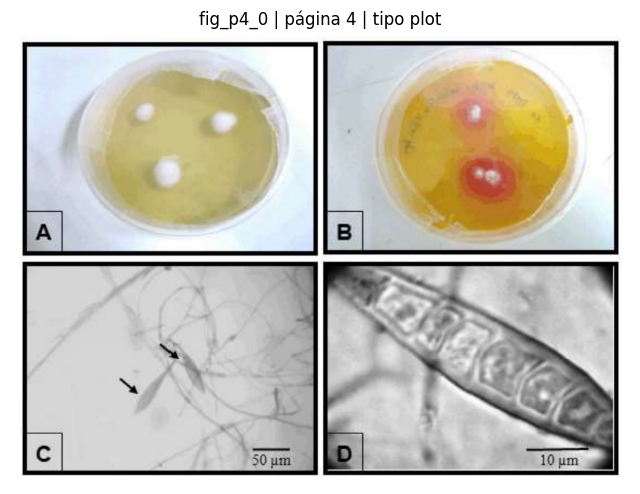

RAW VISUAL CAPTION:
The image is a collage of four photographs showing different types of bacteria. The first photograph on the top left shows a small, round, yellowish-orange substance with three small white spheres on top. The substance appears to be a type of bacteria, possibly a parasite or a parasite. The

CAPTION OCR:


NEARBY TEXT:
gatos inmunocomprometidos. A: Se observan colonias resembradas de M. canis en placa de AGS con 4 dias de desarrollo. B: Se muestran colonias resembradas en agar- DTM con 2 dias de desarrollo. C-D: Flechas apuntan a macroconidios de M. canis observados con KOH 10% TpIno

MENTIONS TEXT:


CONTEXTUAL DESCRIPTION:
Visualmente, la figura parece mostrar The image is a collage of four photographs showing different types of bacteria. The first photograph on the top left shows a small, round, yellowish-orange substance with three small white spheres on top. The substance appears to be a type of bacteria, possibly a parasite or a parasite. The. El texto cercano

In [18]:
def show_figure_result(results: List[Dict[str, Any]], idx: int = 0) -> None:
    result = results[idx]
    img = Image.open(result["image_path"]).convert("RGB")

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{result['figure_id']} | página {result['page_num']} | tipo {result['figure_type']}")
    plt.show()

    print("RAW VISUAL CAPTION:")
    print(result["raw_visual_caption"])
    print()
    print("CAPTION OCR:")
    print(result["caption_text"])
    print()
    print("NEARBY TEXT:")
    print(result["nearby_text"])
    print()
    print("MENTIONS TEXT:")
    print(result["mentions_text"])
    print()
    print("CONTEXTUAL DESCRIPTION:")
    print(result["contextual_description"])

if results:
    show_figure_result(results, idx=0)
else:
    print("No hay resultados para visualizar.")

## 16. Guardado de resultados

In [19]:
with RESULTS_JSON_PATH.open("w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

results_df.to_csv(RESULTS_CSV_PATH, index=False)

print("Resultados JSON:", RESULTS_JSON_PATH)
print("Resultados CSV:", RESULTS_CSV_PATH)

if errors:
    errors_path = OUTPUT_DIR / "contextual_image2text_errors.json"
    with errors_path.open("w", encoding="utf-8") as f:
        json.dump(errors, f, ensure_ascii=False, indent=2)
    print("Errores:", errors_path)

Resultados JSON: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\12_image2text\contextual_image2text_results.json
Resultados CSV: C:\Users\user\proyectos\vision-docs\data\outputs\paper_run_001\12_image2text\contextual_image2text_results.csv


## 17. Siguiente paso recomendado

La siguiente etapa natural es un **Notebook 3** que fusione:

- `page_ocr.csv` o `paper_text.txt`
- `contextual_image2text_results.json`
- tablas extraídas

para construir una representación multimodal del documento antes de pasar a LLM.